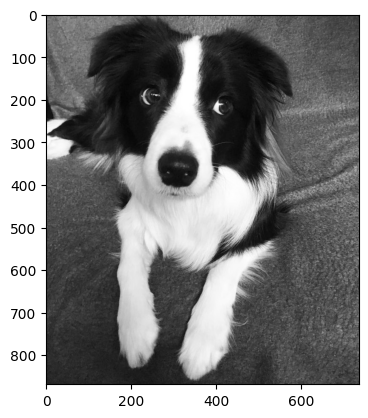

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Загружаем изображение sar_1.jpg и переводим в оттенки серого
image = cv2.imread("sar_1.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Смотрим на исходное изображение
plt.imshow(image_gray, cmap="gray")

Best: (np.float32(350.0), np.float32(0.43633232))


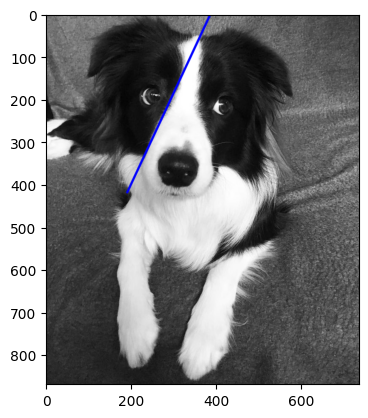

In [32]:
#1 Поиск наиболее протяженного участка
import math
import copy
image_2 = copy.deepcopy(image)
image_gray_no_noise = cv2.medianBlur(image_gray, 13)
canny = cv2.Canny(image_gray_no_noise,50,150,apertureSize = 3)
lines = cv2.HoughLines(canny, 1, np.pi / 180, 47)

ys, xs = np.where(canny > 0)
best = None
mx = 0
for i in range(0, len(lines)):
    rho = lines[i][0][0]
    theta = lines[i][0][1]
    cnt = 0
    for j in range(len(xs)):
        d = abs(xs[j]*math.cos(theta) + ys[j]*math.sin(theta) - rho)
        if d < 1.0:
            cnt = cnt + 1
    if cnt > mx:
        mx = cnt
        best = (rho, theta)

print("Best:", best)

rho = best[0]
theta = best[1]
a = math.cos(theta)
b = math.sin(theta)
x0 = a * rho
y0 = b * rho
pt1 = (int(x0 + 300*(-b)), int(y0 + 300*(a)))
pt2 = (int(x0 - 300*(-b)), int(y0 - 300*(a)))
cv2.line(image_2, pt1, pt2, (0,0,255), 3, cv2.LINE_AA)

plt.imshow(image_2)

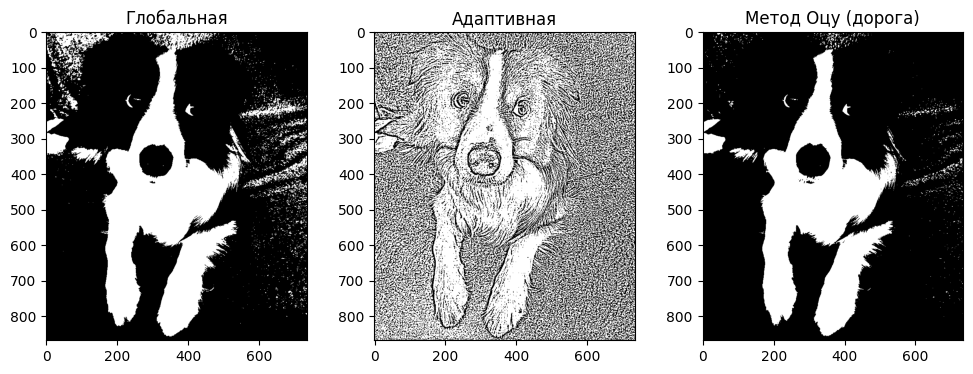

In [31]:
#2 Исследование алгоритмов бинаризации и выделение дорожной полосы
_, thresh_global = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY)

thresh_adaptive = cv2.adaptiveThreshold(
    image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
)
_, thresh_otsu = cv2.threshold(
    image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Глобальная")
plt.imshow(thresh_global, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Адаптивная")
plt.imshow(thresh_adaptive, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Метод Оцу (дорога)")
plt.imshow(thresh_otsu, cmap="gray")

plt.show()